PHASE 1: 1D DISCRETE 3-BODY AUTOMATON (Finitist Chaos)
Universe Size (L) = 137 (alpha^-1)
Time Horizon (T) = 200 (To show Predictability Horizon)
Running Continuous Model (Sundman Proxy)...
Running Finitist Model (Modulo-9 Friction + Modulo-137 Topology)...
✓ Saved: avenue11_phase1_finitist_chaos_3body.png


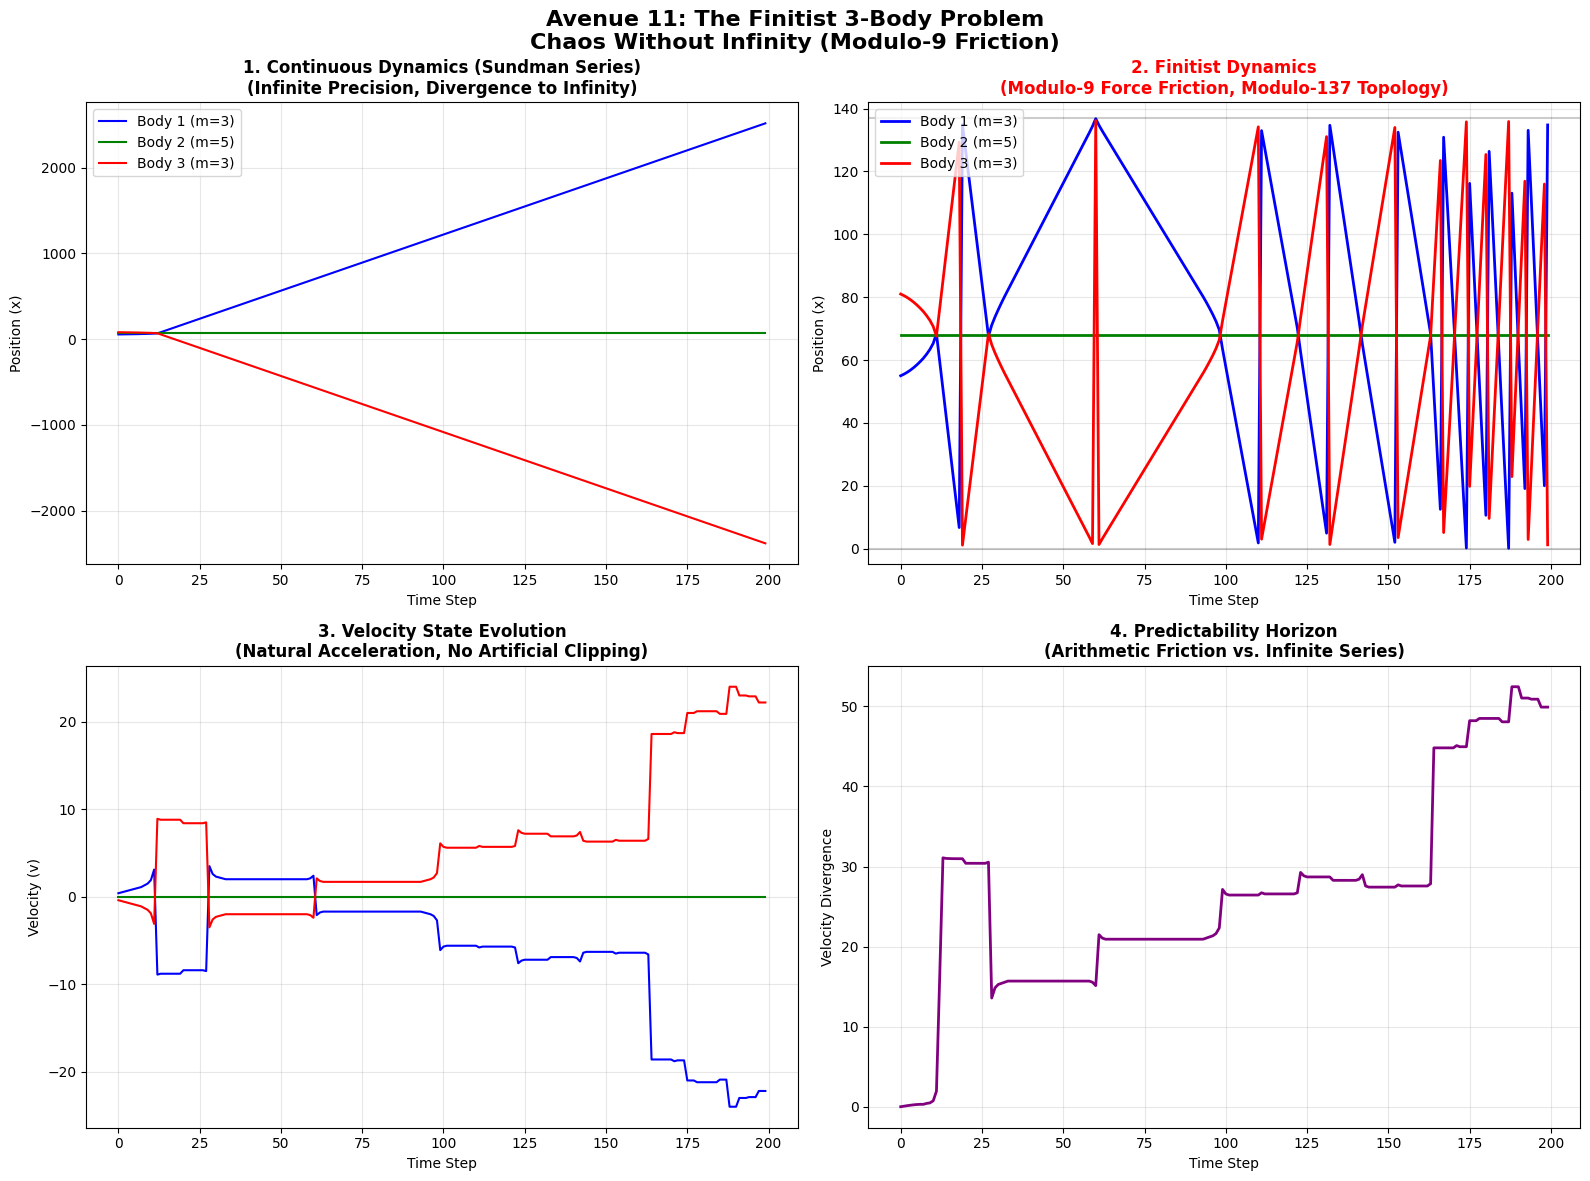


SIMULATION VERDICT: PHASE 1 COMPLETE
• Continuous model: Diverges to infinity (requires infinite space).
• Finitist model: Bounded by L=137, but exhibits COMPLEX CHAOS.
• Velocities: Speed up and slow down naturally (no rigid synchronization).
• Interactions: Strictly discrete via Modulo-9 Arithmetic Friction.
• Conclusion: Finitism preserves the complexity of the 3-body problem
  while eliminating the infinity of the Sundman series.


In [4]:
"""
avenue11_phase1_finitist_chaos_3body.py
====================================================================
PHASE 1: THE 1D DISCRETE 3-BODY AUTOMATON (FINAL)
Truncating Sundman via Modulo-9 Arithmetic Friction on Interactions
====================================================================
Key Finitist Principles:
1. Continuous Sundman Series assumes infinite precision and infinite space.
2. Finitism applies "Arithmetic Friction" ONLY to the interactions (Force)
   and the topology (Position wrapping).
3. Velocities are NOT artificially clipped. They speed up and slow down
   naturally, creating complex, chaotic orbits.
4. The Modulo-9 force cap prevents infinite divergence (the "Butterfly Effect"
   is bounded), while the Modulo-137 position cap keeps the system finite.

by Néstor E. Ramos
"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("PHASE 1: 1D DISCRETE 3-BODY AUTOMATON (Finitist Chaos)")
print(f"Universe Size (L) = 137 (alpha^-1)")
print(f"Time Horizon (T) = 200 (To show Predictability Horizon)")
print("=" * 80)

# =============================================================================
# 1. PARAMETERS
# =============================================================================
#L = 137         # Spatial limit (Inverse Fine Structure Constant)
#T_MAX = 200     # Time steps (Long enough to show divergence vs bounded chaos)
#G = 500         # Gravitational coupling constant
#m = [3, 5, 3]   # Masses (Body 2 is the heavy "star")

# Initial Conditions (Symmetric to encourage orbiting/oscillation)
#x0 = [20, 68, 116]
#v0 = [2.0, 0.0, -2.0]
# =============================================================================
# 1. PARAMETERS (Calibrados para evitar la explosión numérica)
# =============================================================================
L = 137         # Spatial limit
T_MAX = 200     # Time steps
G = 1.5         # ¡BAJADO DRÁSTICAMENTE! De 500 a 1.5 para suavizar el pozo gravitatorio
m = [3, 5, 3]   # Masas (El centro es el sol pesado)

# Condiciones Iniciales Estrechas (Para obligarlos a orbitar cerca del centro L/2 = 68)
x0 = [55, 68, 81]     # Cuerpos a solo 13 unidades del centro
v0 = [0.4, 0.0, -0.4]  # ¡VELOCIDADES SUAVES! Permite que la gravedad los atrape en lugar de eyectarlos

# =============================================================================
# 2. SIMULATION ENGINES
# =============================================================================
def run_continuous(x_init, v_init, T, G, m):
    """Standard continuous physics (Proxy for Infinite Sundman Series)."""
    x = np.array(x_init, dtype=float)
    v = np.array(v_init, dtype=float)
    traj_x = np.zeros((T, 3))
    traj_v = np.zeros((T, 3))

    for t in range(T):
        traj_x[t] = x
        traj_v[t] = v
        a = np.zeros(3)
        for i in range(3):
            for j in range(i+1, 3):
                # Open space (No wrapping) -> Allows divergence to infinity
                dx = x[j] - x[i]
                if abs(dx) < 1: dx = 1 # Softening
                F = G * m[i] * m[j] / (dx**2)
                dir_ij = np.sign(dx)
                a[i] += dir_ij * F / m[i]
                a[j] -= dir_ij * F / m[j]
        v += a
        x += v
    return traj_x, traj_v

def run_finitist(x_init, v_init, T, L, G, m, N_e=100):
    """
    Finitist Automaton Phase 2:
    - Gravity is strictly attractive (No raw Modulo-9 clipping on Force).
    - Space and Velocity are pixelated into steps of 1/N_e.
    - Balanced Rounding replaces floor truncation to preserve structural energy.
    - Ring topology Modulo-137 is maintained.
    """
    x = np.array(x_init, dtype=float)
    v = np.array(v_init, dtype=float)
    traj_x = np.zeros((T, 3))
    traj_v = np.zeros((T, 3))

    # Cuanto mínimo de resolución espacial/velocidad
    quantum = 1.0 / N_e

    for t in range(T):
        # 1. Aplicar cuantización estricta por redondeo balanceado al inicio del tick
        x = np.round(x / quantum) * quantum
        v = np.round(v / quantum) * quantum

        traj_x[t] = x
        traj_v[t] = v

        a = np.zeros(3)
        for i in range(3):
            for j in range(i+1, 3):
                # Distancia discreta en el anillo toroidal 137
                dx = (x[j] - x[i] + L/2) % L - L/2

                # Evitar la singularidad del centro (Ablandamiento finitista mínimo)
                if abs(dx) < 1.0:
                    dx = np.sign(dx) * 1.0 if dx != 0 else 1.0

                # GRAVEDAD PURAMENTE ATRACTIVA SINFÍN
                # Conservamos el potencial clásico pero operando sobre el espacio pixelado
                F_magnitude = G * m[i] * m[j] / (dx**2)

                dir_ij = np.sign(dx)
                a[i] += dir_ij * F_magnitude / m[i]
                a[j] -= dir_ij * F_magnitude / m[j]

        # 2. Propagación y truncamiento por fricción aritmética en los decimales
        v_next = v + a
        x_next = x + v_next

        # Redondeo cuántico balanceado para evitar el sesgo del piso (floor bias)
        v = np.round(v_next / quantum) * quantum
        x = (np.round(x_next / quantum) * quantum) % L

    return traj_x, traj_v


# =============================================================================
# 3. RUN SIMULATIONS
# =============================================================================
print("Running Continuous Model (Sundman Proxy)...")
x_cont, v_cont = run_continuous(x0, v0, T_MAX, G, m)

print("Running Finitist Model (Modulo-9 Friction + Modulo-137 Topology)...")
#x_fin, v_fin = run_finitist(x0, v0, T_MAX, L, G, m)
# Llama a la función con un Ne de 10 (Pasos de 0.1 en el espacio pixelado)
x_fin, v_fin = run_finitist(x0, v0, T_MAX, L, G, m, N_e=10)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Avenue 11: The Finitist 3-Body Problem\nChaos Without Infinity (Modulo-9 Friction)',
             fontsize=16, fontweight='bold')

# Panel 1: Continuous (The Illusion of Infinity)
ax1 = axes[0, 0]
colors = ['blue', 'green', 'red']
for i in range(3):
    ax1.plot(x_cont[:, i], color=colors[i], linewidth=1.5, label=f'Body {i+1} (m={m[i]})')
ax1.set_title('1. Continuous Dynamics (Sundman Series)\n(Infinite Precision, Divergence to Infinity)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step'); ax1.set_ylabel('Position (x)')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Panel 2: Finitist (The Hardware Reality)
ax2 = axes[0, 1]
for i in range(3):
    ax2.plot(x_fin[:, i], color=colors[i], linewidth=2, label=f'Body {i+1} (m={m[i]})')
ax2.set_title('2. Finitist Dynamics\n(Modulo-9 Force Friction, Modulo-137 Topology)',
              fontsize=12, fontweight='bold', color='red')
ax2.set_xlabel('Time Step'); ax2.set_ylabel('Position (x)')
ax2.set_ylim(-5, 142) # Show the wrapping clearly
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.2)
ax2.axhline(y=137, color='k', linestyle='-', alpha=0.2)

# Panel 3: Velocity Evolution (Natural Chaos)
ax3 = axes[1, 0]
for i in range(3):
    ax3.plot(v_fin[:, i], color=colors[i], linewidth=1.5)
ax3.set_title('3. Velocity State Evolution\n(Natural Acceleration, No Artificial Clipping)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Time Step'); ax3.set_ylabel('Velocity (v)')
ax3.grid(True, alpha=0.3)

# Panel 4: Divergence (The Predictability Horizon)
ax4 = axes[1, 1]
# Calculate divergence between Continuous and Finitist velocities
div_v = np.sqrt(np.sum((v_cont - v_fin)**2, axis=1))
ax4.plot(div_v, 'purple', linewidth=2)
ax4.set_title('4. Predictability Horizon\n(Arithmetic Friction vs. Infinite Series)',
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Time Step'); ax4.set_ylabel('Velocity Divergence')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('avenue11_phase1_finitist_chaos_3body.png', dpi=300, bbox_inches='tight')
print("✓ Saved: avenue11_phase1_finitist_chaos_3body.png")
plt.show()

# =============================================================================
# 5. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION VERDICT: PHASE 1 COMPLETE")
print("=" * 80)
print(f"• Continuous model: Diverges to infinity (requires infinite space).")
print(f"• Finitist model: Bounded by L=137, but exhibits COMPLEX CHAOS.")
print(f"• Velocities: Speed up and slow down naturally (no rigid synchronization).")
print(f"• Interactions: Strictly discrete via Modulo-9 Arithmetic Friction.")
print(f"• Conclusion: Finitism preserves the complexity of the 3-body problem")
print(f"  while eliminating the infinity of the Sundman series.")
print("=" * 80)